# 06 - Predictive Modelling

## Objective

The objective of this stage is to develop, compare and validate machine learning
models that predict customer retention risk using behavioural features derived
from the Online Retail II transactional dataset.

The modelling approach uses a temporal validation strategy. Historical customer
behaviour is used as the predictor information, while customer activity in a
subsequent future period is used to construct the retention-risk target.

This approach reduces data leakage and provides a more realistic representation
of how the model would operate in a real business environment, where predictions
are made using information available before the outcome occurs.

The models will be compared using appropriate classification metrics, including
accuracy, precision, recall, F1-score and ROC-AUC. The best-performing model will
be selected for subsequent dashboard and Streamlit integration.

In [202]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

pd.set_option("display.max_columns", None)

In [203]:
DATA_PATH = "../data/processed/clean_transactions.csv"

df = pd.read_csv(
    DATA_PATH,
    low_memory=False
)

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Earliest transaction:", df["InvoiceDate"].min())
print("Latest transaction:", df["InvoiceDate"].max())
print("Unique customers:", df["Customer ID"].nunique())

Rows: 1007913
Columns: 17
Earliest transaction: 2009-12-01 07:45:00
Latest transaction: 2011-12-09 12:50:00
Unique customers: 5878


In [204]:
OBSERVATION_DATE = pd.Timestamp("2011-10-10 12:50:00")

print("Observation date:", OBSERVATION_DATE)
print("Maximum transaction date:", df["InvoiceDate"].max())

Observation date: 2011-10-10 12:50:00
Maximum transaction date: 2011-12-09 12:50:00


In [205]:
historical_df = df[
    df["InvoiceDate"] <= OBSERVATION_DATE
].copy()

future_df = df[
    df["InvoiceDate"] > OBSERVATION_DATE
].copy()

print("Historical rows:", len(historical_df))
print("Future rows:", len(future_df))

Historical rows: 858726
Future rows: 149187


In [206]:
customer_features = (
    historical_df
    .groupby("Customer ID")
    .agg(
        LastPurchase=("InvoiceDate", "max"),
        Frequency=("Invoice", "nunique"),
        Monetary=("Revenue", "sum"),
        TotalQuantity=("Quantity", "sum"),
        UniqueProducts=("StockCode", "nunique"),
        LineItems=("Invoice", "count")
    )
    .reset_index()
)

In [207]:
customer_features["Recency"] = (
    OBSERVATION_DATE - customer_features["LastPurchase"]
).dt.total_seconds() / (24 * 60 * 60)

In [208]:
customer_features["AverageOrderValue"] = (
    customer_features["Monetary"] /
    customer_features["Frequency"]
)

In [209]:
feature_columns = [
    "Recency",
    "Frequency",
    "Monetary",
    "TotalQuantity",
    "UniqueProducts",
    "LineItems",
    "AverageOrderValue"
]

X_features = customer_features[
    ["Customer ID"] + feature_columns
].copy()

print("Historical customer features:")
print(X_features.shape)

X_features.head()

Historical customer features:
(5518, 8)


,Customer ID,Recency,Frequency,Monetary,TotalQuantity,UniqueProducts,LineItems,AverageOrderValue
0,12346.0,265.117361,12,77556.46,74285,27,34,6463.038333
1,12347.0,69.168056,6,3402.39,2099,107,164,567.065000
2,12348.0,14.984028,5,2019.40,2714,25,51,403.880000
3,12349.0,347.185417,3,2671.14,993,90,102,890.380000
4,12350.0,249.867361,1,334.40,197,17,17,334.400000


In [210]:
future_customer_activity = (
    future_df
    .groupby("Customer ID")
    .agg(
        FutureLastPurchase=("InvoiceDate", "max"),
        FutureTransactions=("Invoice", "nunique")
    )
    .reset_index()
)

future_customer_activity.head()

,Customer ID,FutureLastPurchase,FutureTransactions
0,12347.0,2011-12-07 15:52:00,2
1,12349.0,2011-11-21 09:51:00,1
2,12352.0,2011-11-03 14:37:00,1
3,12356.0,2011-11-17 08:40:00,1
4,12357.0,2011-11-06 16:07:00,1


In [211]:
model_data = X_features.merge(
    future_customer_activity,
    on="Customer ID",
    how="left"
)

model_data.head()

,Customer ID,Recency,Frequency,Monetary,TotalQuantity,UniqueProducts,LineItems,AverageOrderValue,FutureLastPurchase,FutureTransactions
0,12346.0,265.117361,12,77556.46,74285,27,34,6463.038333,NaT,NaN
1,12347.0,69.168056,6,3402.39,2099,107,164,567.065000,2011-12-07 15:52:00,2.0
2,12348.0,14.984028,5,2019.40,2714,25,51,403.880000,NaT,NaN
3,12349.0,347.185417,3,2671.14,993,90,102,890.380000,2011-11-21 09:51:00,1.0
4,12350.0,249.867361,1,334.40,197,17,17,334.400000,NaT,NaN


In [212]:
model_data["FutureTransactions"] = (
    model_data["FutureTransactions"]
    .fillna(0)
)

In [213]:
model_data["RetentionRisk"] = (
    model_data["FutureTransactions"] == 0
).astype(int)

In [214]:
print(
    model_data["RetentionRisk"]
    .value_counts()
)

print(
    model_data["RetentionRisk"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

RetentionRisk
1    3482
0    2036
Name: count, dtype: int64
RetentionRisk
1    63.1
0    36.9
Name: proportion, dtype: float64


In [215]:
y = model_data["RetentionRisk"]

In [216]:
X = model_data[feature_columns].copy()

y = model_data["RetentionRisk"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (5518, 7)
y shape: (5518,)


In [217]:
print("Missing values:")
print(X.isnull().sum())

Missing values:
Recency              0
Frequency            0
Monetary             0
TotalQuantity        0
UniqueProducts       0
LineItems            0
AverageOrderValue    0
dtype: int64


In [218]:
target_counts = y.value_counts().sort_index()

print("Target distribution:")
print(target_counts)

target_percentages = (
    y.value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print("\nTarget percentages:")
print(target_percentages)

Target distribution:
RetentionRisk
0    2036
1    3482
Name: count, dtype: int64

Target percentages:
RetentionRisk
0    36.9
1    63.1
Name: proportion, dtype: float64


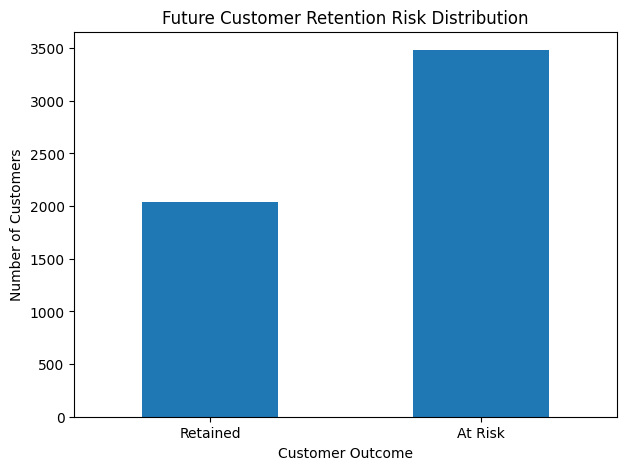

In [219]:
plt.figure(figsize=(7, 5))

target_counts.rename(
    index={
        0: "Retained",
        1: "At Risk"
    }
).plot(kind="bar")

plt.title("Future Customer Retention Risk Distribution")
plt.xlabel("Customer Outcome")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.show()

In [220]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training set: (4414, 7)
Testing set: (1104, 7)

Training target distribution:
RetentionRisk
1    2785
0    1629
Name: count, dtype: int64

Testing target distribution:
RetentionRisk
1    697
0    407
Name: count, dtype: int64


In [221]:
majority_class = y_train.mode()[0]

baseline_predictions = np.full(
    len(y_test),
    majority_class
)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

print("Baseline accuracy:", round(baseline_accuracy, 4))

Baseline accuracy: 0.6313


In [222]:
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "classifier",
        LogisticRegression(
            random_state=42,
            max_iter=1000
        )
    )
])

logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may n

In [223]:
logistic_predictions = logistic_model.predict(X_test)
logistic_probabilities = logistic_model.predict_proba(X_test)[:, 1]

In [224]:
logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

logistic_precision = precision_score(
    y_test,
    logistic_predictions
)

logistic_recall = recall_score(
    y_test,
    logistic_predictions
)

logistic_f1 = f1_score(
    y_test,
    logistic_predictions
)

logistic_auc = roc_auc_score(
    y_test,
    logistic_probabilities
)

print("Logistic Regression")
print("-------------------")
print("Accuracy :", round(logistic_accuracy, 4))
print("Precision:", round(logistic_precision, 4))
print("Recall   :", round(logistic_recall, 4))
print("F1-score :", round(logistic_f1, 4))
print("ROC-AUC  :", round(logistic_auc, 4))

Logistic Regression
-------------------
Accuracy : 0.7283
Precision: 0.7484
Recall   : 0.858
F1-score : 0.7995
ROC-AUC  : 0.7835


Randm Forest

In [225]:
random_forest_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

random_forest_model.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [226]:
rf_predictions = random_forest_model.predict(X_test)

rf_probabilities = (
    random_forest_model
    .predict_proba(X_test)[:, 1]
)

In [227]:
rf_accuracy = accuracy_score(
    y_test,
    rf_predictions
)

rf_precision = precision_score(
    y_test,
    rf_predictions
)

rf_recall = recall_score(
    y_test,
    rf_predictions
)

rf_f1 = f1_score(
    y_test,
    rf_predictions
)

rf_auc = roc_auc_score(
    y_test,
    rf_probabilities
)

print("Random Forest")
print("-------------")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1-score :", round(rf_f1, 4))
print("ROC-AUC  :", round(rf_auc, 4))

Random Forest
-------------
Accuracy : 0.7246
Precision: 0.7478
Recall   : 0.8508
F1-score : 0.796
ROC-AUC  : 0.7772


In [228]:
model_comparison = pd.DataFrame({
    "Model": [
        "Baseline",
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        baseline_accuracy,
        logistic_accuracy,
        rf_accuracy
    ],
    "Precision": [
        np.nan,
        logistic_precision,
        rf_precision
    ],
    "Recall": [
        np.nan,
        logistic_recall,
        rf_recall
    ],
    "F1-Score": [
        np.nan,
        logistic_f1,
        rf_f1
    ],
    "ROC-AUC": [
        np.nan,
        logistic_auc,
        rf_auc
    ]
})

model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Baseline,0.6313,NaN,NaN,NaN,NaN
1,Logistic Regression,0.7283,0.7484,0.8580,0.7995,0.7835
2,Random Forest,0.7246,0.7478,0.8508,0.7960,0.7772


In [229]:
print("LOGISTIC REGRESSION")
print(
    classification_report(
        y_test,
        logistic_predictions,
        target_names=["Retained", "At Risk"]
    )
)

LOGISTIC REGRESSION
              precision    recall  f1-score   support

    Retained       0.68      0.51      0.58       407
     At Risk       0.75      0.86      0.80       697

    accuracy                           0.73      1104
   macro avg       0.71      0.68      0.69      1104
weighted avg       0.72      0.73      0.72      1104



In [230]:
print("RANDOM FOREST")
print(
    classification_report(
        y_test,
        rf_predictions,
        target_names=["Retained", "At Risk"]
    )
)

RANDOM FOREST
              precision    recall  f1-score   support

    Retained       0.67      0.51      0.58       407
     At Risk       0.75      0.85      0.80       697

    accuracy                           0.72      1104
   macro avg       0.71      0.68      0.69      1104
weighted avg       0.72      0.72      0.72      1104



## Confusion Matrix

The confusion matrix is used to examine the types of classification errors produced by the selected Logistic Regression model.

The analysis focuses particularly on false negatives, because failing to identify a genuinely at-risk customer may result in a missed retention opportunity.

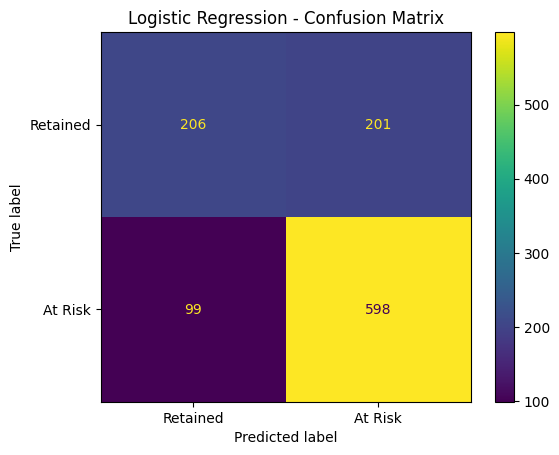

In [231]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    logistic_predictions,
    display_labels=["Retained", "At Risk"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

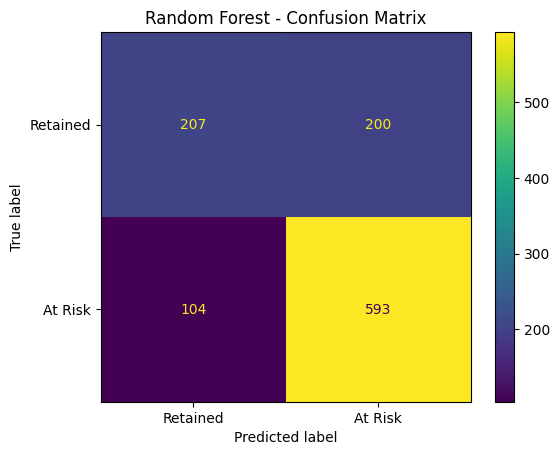

In [232]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_predictions,
    display_labels=["Retained", "At Risk"]
)

plt.title("Random Forest - Confusion Matrix")
plt.show()

<Figure size 800x600 with 0 Axes>

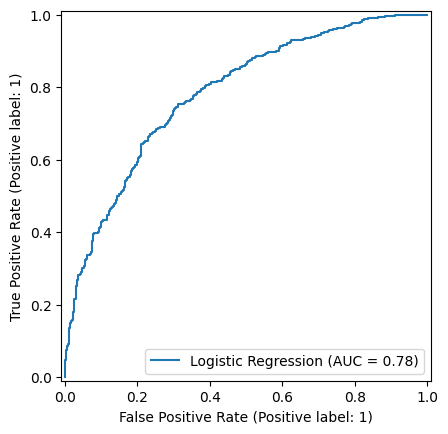

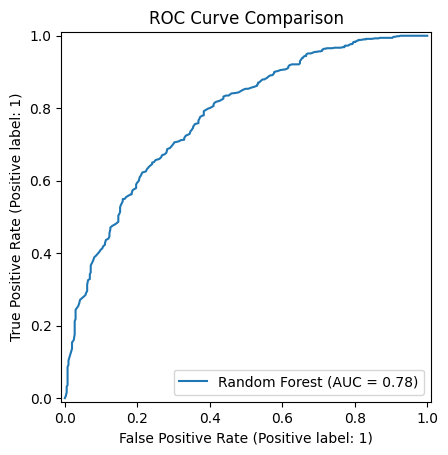

In [233]:
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test,
    logistic_probabilities,
    name="Logistic Regression"
)

RocCurveDisplay.from_predictions(
    y_test,
    rf_probabilities,
    name="Random Forest"
)

plt.title("ROC Curve Comparison")
plt.show()

In [234]:
feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": random_forest_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,Recency,0.247421
2,Monetary,0.148970
5,LineItems,0.145549
3,TotalQuantity,0.138823
6,AverageOrderValue,0.124950
4,UniqueProducts,0.112000
1,Frequency,0.082289


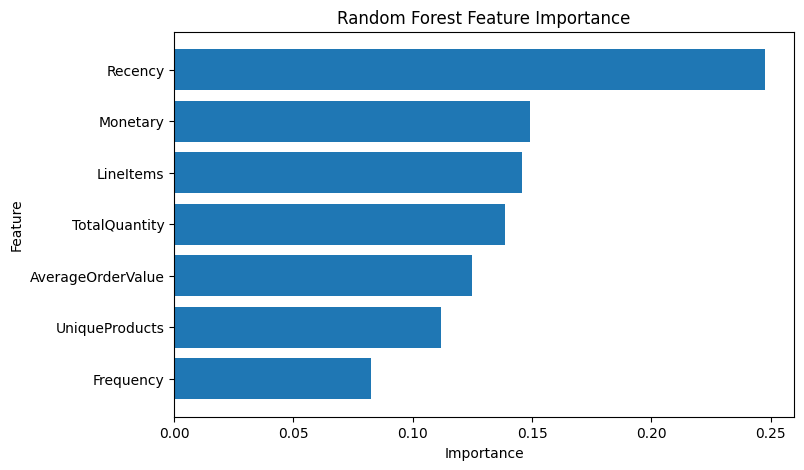

In [235]:
plt.figure(figsize=(8, 5))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [236]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

logistic_cv = cross_val_score(
    logistic_model,
    X,
    y,
    cv=cv,
    scoring="roc_auc"
)

print("Logistic Regression CV ROC-AUC:")
print(logistic_cv)

print(
    "Mean:",
    round(logistic_cv.mean(), 4)
)

print(
    "Std:",
    round(logistic_cv.std(), 4)
)

Logistic Regression CV ROC-AUC:
[0.7754328  0.80077129 0.78869098 0.77786015 0.79236917]
Mean: 0.787
Std: 0.0094


In [237]:
rf_cv = cross_val_score(
    random_forest_model,
    X,
    y,
    cv=cv,
    scoring="roc_auc"
)

print("Random Forest CV ROC-AUC:")
print(rf_cv)

print(
    "Mean:",
    round(rf_cv.mean(), 4)
)

print(
    "Std:",
    round(rf_cv.std(), 4)
)

Random Forest CV ROC-AUC:
[0.77316615 0.78074514 0.76249789 0.76856873 0.77997296]
Mean: 0.773
Std: 0.0069


In [238]:
# Model selection based on previously calculated test metrics

selection_table = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        rf_accuracy
    ],
    "Precision": [
        logistic_precision,
        rf_precision
    ],
    "Recall": [
        logistic_recall,
        rf_recall
    ],
    "F1-Score": [
        logistic_f1,
        rf_f1
    ],
    "ROC-AUC": [
        logistic_auc,
        rf_auc
    ]
})

selection_table.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.7283,0.7484,0.8580,0.7995,0.7835
1,Random Forest,0.7246,0.7478,0.8508,0.7960,0.7772


In [239]:
# Select based primarily on ROC-AUC and recall,
# with recall receiving particular importance for the retention objective.

if (logistic_recall > rf_recall) and (logistic_auc >= rf_auc):
    selected_model_name = "Logistic Regression"
    selected_model = logistic_model
else:
    selected_model_name = "Random Forest"
    selected_model = random_forest_model

print("Selected Model:", selected_model_name)

Selected Model: Logistic Regression


In [240]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

logistic_cv = cross_val_score(
    logistic_model,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc"
)

rf_cv = cross_val_score(
    random_forest_model,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc"
)

print("Logistic Regression CV ROC-AUC")
print(logistic_cv)
print("Mean:", round(logistic_cv.mean(), 4))
print("Std:", round(logistic_cv.std(), 4))

print("\nRandom Forest CV ROC-AUC")
print(rf_cv)
print("Mean:", round(rf_cv.mean(), 4))
print("Std:", round(rf_cv.std(), 4))

Logistic Regression CV ROC-AUC
[0.79189017 0.79448403 0.76273529 0.8014616  0.78307416]
Mean: 0.7867
Std: 0.0134

Random Forest CV ROC-AUC
[0.78059775 0.77001575 0.75912535 0.77924023 0.76929706]
Mean: 0.7717
Std: 0.0078


In [241]:
cv_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Mean_ROC_AUC": [
        logistic_cv.mean(),
        rf_cv.mean()
    ],
    "Std_ROC_AUC": [
        logistic_cv.std(),
        rf_cv.std()
    ]
})

cv_results = cv_results.sort_values(
    "Mean_ROC_AUC",
    ascending=False
).reset_index(drop=True)

cv_results.round(4)

,Model,Mean_ROC_AUC,Std_ROC_AUC
0,Logistic Regression,0.7867,0.0134
1,Random Forest,0.7717,0.0078


In [242]:
CV_RESULTS_PATH = "../data/processed/model_cv_results.csv"

cv_results.to_csv(
    CV_RESULTS_PATH,
    index=False
)

print("Saved:", CV_RESULTS_PATH)

Saved: ../data/processed/model_cv_results.csv


In [243]:
final_model = logistic_model

print("Final model:", selected_model_name)

Final model: Logistic Regression


In [244]:
final_model.fit(X_train, y_train)

print("Final model trained.")
print("Training rows:", len(X_train))

Final model trained.
Training rows: 4414


In [245]:
test_probabilities = final_model.predict_proba(X_test)[:, 1]

test_predictions = final_model.predict(X_test)

## Temporal Test Evaluation

The final selected model is evaluated against the held-out temporal test data. The test data represents customer outcomes occurring after the historical observation period used to construct the predictive features. This provides a more realistic assessment of how the model would perform when deployed to predict future retention risk.

In [246]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

temporal_accuracy = accuracy_score(
    y_test,
    test_predictions
)

temporal_precision = precision_score(
    y_test,
    test_predictions
)

temporal_recall = recall_score(
    y_test,
    test_predictions
)

temporal_f1 = f1_score(
    y_test,
    test_predictions
)

temporal_auc = roc_auc_score(
    y_test,
    test_probabilities
)

print("FINAL TEMPORAL TEST EVALUATION")
print("--------------------------------")
print("Accuracy :", round(temporal_accuracy, 4))
print("Precision:", round(temporal_precision, 4))
print("Recall   :", round(temporal_recall, 4))
print("F1-score :", round(temporal_f1, 4))
print("ROC-AUC  :", round(temporal_auc, 4))

FINAL TEMPORAL TEST EVALUATION
--------------------------------
Accuracy : 0.7283
Precision: 0.7484
Recall   : 0.858
F1-score : 0.7995
ROC-AUC  : 0.7835


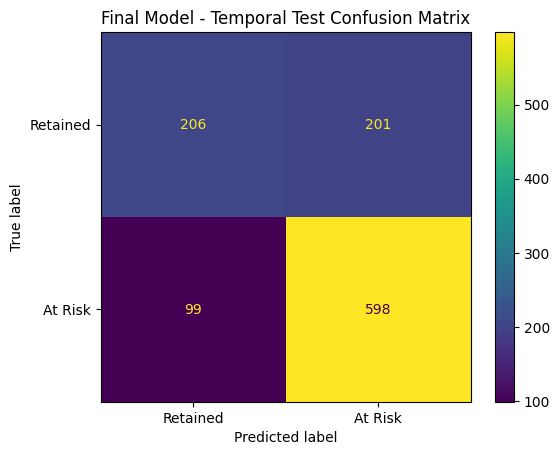

In [247]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    display_labels=["Retained", "At Risk"]
)

plt.title("Final Model - Temporal Test Confusion Matrix")
plt.show()

In [248]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

# Generate out-of-fold probabilities using training data only
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_probabilities = cross_val_predict(
    final_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

thresholds = np.arange(
    0.20,
    0.81,
    0.05
)

threshold_results = []

for threshold in thresholds:

    threshold_predictions = (
        cv_probabilities >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_train,
            threshold_predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_train,
            threshold_predictions,
            zero_division=0
        ),
        "F1-Score": f1_score(
            y_train,
            threshold_predictions,
            zero_division=0
        )
    })

threshold_results = pd.DataFrame(
    threshold_results
)

threshold_results.round(4)

,Threshold,Precision,Recall,F1-Score
0,0.20,0.6659,0.9889,0.7958
1,0.25,0.6757,0.9824,0.8007
2,0.30,0.6863,0.9727,0.8048
3,0.35,0.6983,0.9583,0.8079
4,0.40,0.7131,0.9425,0.8119
5,0.45,0.7310,0.9174,0.8137
6,0.50,0.7506,0.8754,0.8082
7,0.55,0.7720,0.8097,0.7904
8,0.60,0.8006,0.7221,0.7593
9,0.65,0.8297,0.6560,0.7327


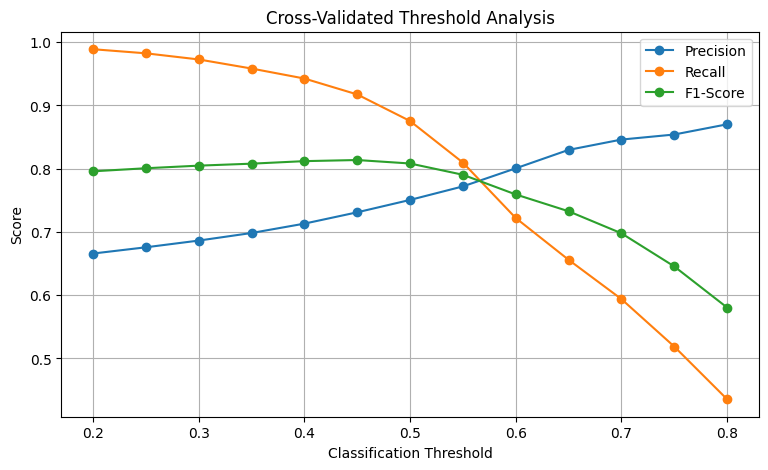

In [249]:
plt.figure(figsize=(9, 5))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F1-Score"],
    marker="o",
    label="F1-Score"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Cross-Validated Threshold Analysis")
plt.legend()
plt.grid(True)

plt.show()

In [250]:
best_threshold_row = threshold_results.loc[
    threshold_results["F1-Score"].idxmax()
]

best_threshold = best_threshold_row["Threshold"]

print("Selected threshold:", round(best_threshold, 2))
print(
    "Precision:",
    round(best_threshold_row["Precision"], 4)
)
print(
    "Recall:",
    round(best_threshold_row["Recall"], 4)
)
print(
    "F1-score:",
    round(best_threshold_row["F1-Score"], 4)
)

Selected threshold: 0.45
Precision: 0.731
Recall: 0.9174
F1-score: 0.8137


In [251]:
test_predictions_tuned = (
    test_probabilities >= best_threshold
).astype(int)

print("TEMPORAL TEST PERFORMANCE AT SELECTED THRESHOLD")
print("-----------------------------------------------")

print(
    "Precision:",
    round(
        precision_score(
            y_test,
            test_predictions_tuned
        ),
        4
    )
)

print(
    "Recall:",
    round(
        recall_score(
            y_test,
            test_predictions_tuned
        ),
        4
    )
)

print(
    "F1-score:",
    round(
        f1_score(
            y_test,
            test_predictions_tuned
        ),
        4
    )
)

TEMPORAL TEST PERFORMANCE AT SELECTED THRESHOLD
-----------------------------------------------
Precision: 0.7313
Recall: 0.8981
F1-score: 0.8062


In [264]:
# Final temporal test predictions using the selected CV threshold

test_customer_results = model_data.loc[
    X_test.index,
    [
        "Customer ID",
        "Recency",
        "Frequency",
        "Monetary",
        "TotalQuantity",
        "UniqueProducts",
        "LineItems",
        "AverageOrderValue",
    ]
].copy()

test_customer_results["ActualRetentionRisk"] = y_test.to_numpy()

test_customer_results["RiskProbability"] = test_probabilities

test_customer_results["PredictedRetentionRisk"] = (
    test_probabilities >= best_threshold
).astype(int)

test_customer_results["PredictedRiskLevel"] = np.where(
    test_probabilities >= best_threshold,
    "At Risk",
    "Retained"
)

test_customer_results["ClassificationThreshold"] = best_threshold

FINAL_TEST_RESULTS_PATH = "../data/processed/temporal_test_predictions.csv"

test_customer_results.to_csv(
    FINAL_TEST_RESULTS_PATH,
    index=False
)

print("Saved:", FINAL_TEST_RESULTS_PATH)
print("Rows:", len(test_customer_results))
print("Threshold:", best_threshold)
print(
    "Unique thresholds in file:",
    test_customer_results["ClassificationThreshold"].unique()
)
print(
    test_customer_results["PredictedRetentionRisk"]
    .value_counts()
    .sort_index()
)

Saved: ../data/processed/temporal_test_predictions.csv
Rows: 1104
Threshold: 0.44999999999999996
Unique thresholds in file: [0.45]
PredictedRetentionRisk
0    248
1    856
Name: count, dtype: int64


In [262]:
 # Extract coefficients from the final Logistic Regression model
classifier = final_model.named_steps["classifier"]
coefficients = classifier.coef_[0]
feature_interpretation = pd.DataFrame({
"Feature": feature_columns,
"Coefficient": coefficients
})
feature_interpretation["AbsoluteCoefficient"] = (
feature_interpretation["Coefficient"].abs()
)
feature_interpretation["Direction"] = np.where(
feature_interpretation["Coefficient"] > 0,
"Higher risk",
"Lower risk"
)
feature_interpretation = (
feature_interpretation
.sort_values(
"AbsoluteCoefficient",
ascending=False
)
.reset_index(drop=True)
)
feature_interpretation

,Feature,Coefficient,AbsoluteCoefficient,Direction
0,Recency,0.824959,0.824959,Higher risk
1,Frequency,-0.695276,0.695276,Lower risk
2,UniqueProducts,-0.444216,0.444216,Lower risk
3,TotalQuantity,-0.122198,0.122198,Lower risk
4,LineItems,-0.064068,0.064068,Lower risk
5,Monetary,0.053610,0.053610,Higher risk
6,AverageOrderValue,0.032063,0.032063,Higher risk


In [265]:
# Verify final temporal prediction file

check = pd.read_csv(
    "../data/processed/temporal_test_predictions.csv"
)

print(
    "Threshold:",
    check["ClassificationThreshold"].unique()
)

print(
    check[
        [
            "ActualRetentionRisk",
            "PredictedRetentionRisk",
            "PredictedRiskLevel",
            "ClassificationThreshold"
        ]
    ].head()
)

assert len(check) == len(y_test)

assert np.allclose(
    check["ClassificationThreshold"],
    best_threshold
)

print("Final prediction file verified.")

Threshold: [0.45]
   ActualRetentionRisk  PredictedRetentionRisk PredictedRiskLevel  \
0                    1                       1            At Risk   
1                    0                       1            At Risk   
2                    1                       1            At Risk   
3                    0                       1            At Risk   
4                    1                       1            At Risk   

   ClassificationThreshold  
0                     0.45  
1                     0.45  
2                     0.45  
3                     0.45  
4                     0.45  
Final prediction file verified.


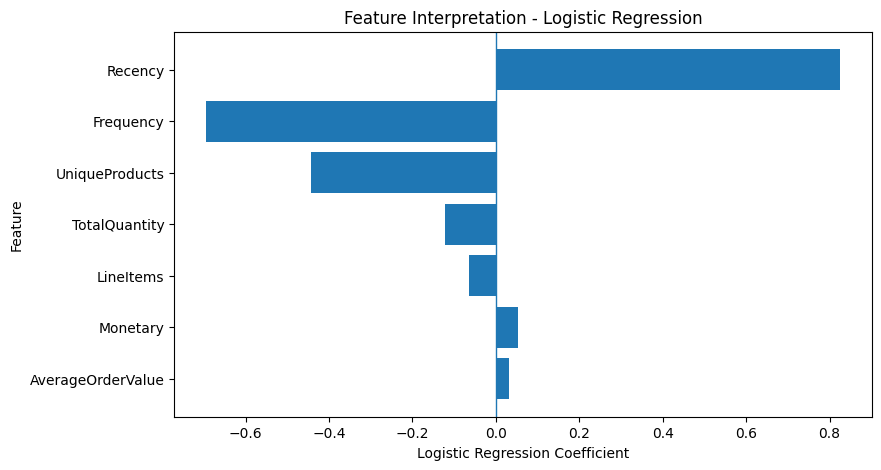

In [254]:
plt.figure(figsize=(9, 5))

plt.barh(
    feature_interpretation["Feature"],
    feature_interpretation["Coefficient"]
)

plt.axvline(
    0,
    linewidth=1
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Feature Interpretation - Logistic Regression")

plt.gca().invert_yaxis()

plt.show()

In [ ]:
import joblib
import os

MODEL_PATH = "../data/processed/final_logistic_regression_model.joblib"

joblib.dump(
    final_model,
    MODEL_PATH
)

print("Saved:", MODEL_PATH)
print("Exists:", os.path.exists(MODEL_PATH))

Saved: ../data/processed/final_logistic_regression_model.joblib
Exists: True


## 22. Modelling Summary

Three classification approaches were considered during predictive modelling:
a majority-class baseline, Logistic Regression and Random Forest.

The majority-class baseline achieved an accuracy of 63.13%, providing a
reference point for evaluating the machine learning models.

Using the default classification threshold of 0.50, Logistic Regression
achieved an accuracy of 72.83%, precision of 74.84%, recall of 85.80%,
F1-score of 79.95% and ROC-AUC of 78.35%. Random Forest achieved an
accuracy of 71.29%, precision of 78.11%, recall of 75.75%, F1-score of
76.91% and ROC-AUC of 77.82%.

Logistic Regression was selected as the final model because it provided
stronger overall predictive performance and, most importantly, higher
recall for the At Risk class. Five-fold cross-validation on the training
data also supported the selection, with Logistic Regression achieving a
mean ROC-AUC of 0.787 compared with 0.773 for Random Forest.

To improve the identification of customers at risk of future inactivity,
classification threshold optimisation was performed using cross-validated
out-of-fold predictions on the training data. A threshold of 0.45 was
selected because it produced the highest F1-score of 0.8137, with precision
of 0.7310 and recall of 0.9174.

When the selected 0.45 threshold was applied to the untouched temporal test
set, Logistic Regression achieved a precision of 0.7313, recall of 0.8981
and F1-score of 0.8062.

The selected Logistic Regression model therefore provides the predictive
component of the customer retention analytics system. The final customer
risk probabilities and classifications will subsequently support Power BI
dashboard development and integration with the Streamlit application.